# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 09 — Robustness, Bootstrap & Monte Carlo Stress Testing

**Purpose:** test whether the strongest pre-holdout findings survive reasonable perturbations of sample order, costs, subperiods, and model-selection assumptions.

Notebook 09 does **not** search for new signal parameters and does **not** access 2026.

### Strategies under examination

Notebook 08 leaves two principal pre-holdout candidates:

1. **Pure Dual Trend**
   - 13/52 dual-horizon trend
   - hierarchical inverse volatility

2. **Walk-Forward Blend Selector**
   - five fixed blend choices between SuperbCommand and Dual Trend
   - 5-year training / 1-year test
   - training Sharpe selection, Calmar tie-breaker

The fixed SuperbCommand leg remains:

- `PT_REDUCE_25`
- hierarchical inverse volatility

### Main robustness questions

Notebook 09 asks:

- Is the WF selector's advantage concentrated in a small number of weeks or years?
- Does it survive higher assumed implementation costs?
- Does it survive block-bootstrap resampling?
- Does it survive leave-one-year-out diagnostics?
- Does it survive removing the best year?
- How sensitive is the selector to modest changes in the **selection framework**, not the underlying signal?
- Does pure Dual Trend remain the safer default when uncertainty is considered?

### Bootstrap philosophy

Weekly returns are serially dependent, so independent IID shuffling is inappropriate.

Notebook 09 therefore uses a **moving-block bootstrap** with fixed 13-week blocks to approximately preserve short-run temporal dependence.

### Holdout discipline

Research ends:

**31 December 2025**

The entire 2026 holdout remains untouched.


In [1]:
# ============================================================
# 9.1 — IMPORTS, DRIVE & CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 09 cannot run with the 2026 holdout unlocked.")

WF_PATH = PATHS["data_processed"] / "08_composite_walkforward_return.parquet"
BLEND_PATH = PATHS["data_processed"] / "08_composite_return_panel.parquet"
BASELINE_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"
WF_SELECTION_PATH = PATHS["results"] / "08_composite_walkforward_selection.csv"

for p in [WF_PATH, BLEND_PATH, BASELINE_PATH, WF_SELECTION_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 9.2 — LOAD PRINCIPAL SERIES
# ============================================================
wf_df = pd.read_parquet(WF_PATH)
blend_panel = pd.read_parquet(BLEND_PATH)
baseline_panel = pd.read_parquet(BASELINE_PATH)
wf_selection = pd.read_csv(WF_SELECTION_PATH)

if wf_df.index.max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in WF blend series.")
if blend_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in blend panel.")
if baseline_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in baseline panel.")

wf = wf_df.iloc[:, 0].rename("WF_BLEND_SELECTOR")

DUAL_KEY = ("DUAL_TREND_13_52", "hier_inverse_vol")
if DUAL_KEY not in baseline_panel.columns:
    raise KeyError(f"Missing benchmark: {DUAL_KEY}")

dual = baseline_panel[DUAL_KEY].rename("DUAL_TREND")

common = pd.concat([wf, dual], axis=1).dropna()
common = common.loc[:RESEARCH_END]

print("Common robustness sample:", common.index.min().date(), "→", common.index.max().date())
print("Weeks:", len(common))
display(common.tail())


Common robustness sample: 2011-01-07 → 2025-12-26
Weeks: 782


,WF_BLEND_SELECTOR,DUAL_TREND
date,,
2025-11-28,0.007753,0.006927
2025-12-05,-0.001729,-0.000803
2025-12-12,-0.001575,-0.001138
2025-12-19,0.001880,0.002110
2025-12-26,0.005128,0.006115


## 9.3 Core performance functions


In [3]:
# ============================================================
# 9.3 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    d = r[r < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / d.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }

base_perf = pd.DataFrame({
    "WF_BLEND_SELECTOR": metrics(common["WF_BLEND_SELECTOR"]),
    "DUAL_TREND": metrics(common["DUAL_TREND"]),
}).T

display(base_perf)


,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week,positive_week_rate
WF_BLEND_SELECTOR,782.0,0.047762,0.031830,1.482315,2.135838,-0.040895,1.167906,-0.027334,0.584399
DUAL_TREND,782.0,0.045304,0.030892,1.450324,2.092592,-0.040895,1.107815,-0.027334,0.579284


## 9.4 Concentration of excess performance

The WF selector's total advantage may be driven by only a few extreme observations.

We therefore inspect:

- weekly excess-return distribution;
- contribution of the best 1, 5, 10 and 20 weeks;
- contribution of the best calendar year.


In [4]:
# ============================================================
# 9.4 — EXCESS-RETURN CONCENTRATION
# ============================================================
excess = (common["WF_BLEND_SELECTOR"] - common["DUAL_TREND"]).rename("weekly_excess")

total_excess_sum = excess.sum()

concentration_rows = []

for n in [1, 5, 10, 20]:
    top = excess.nlargest(n).sum()
    concentration_rows.append({
        "top_weeks": n,
        "sum_top_excess": top,
        "share_of_total_excess_sum": top / total_excess_sum if total_excess_sum != 0 else np.nan,
    })

excess_concentration = pd.DataFrame(concentration_rows)
display(excess_concentration)

yearly_excess = excess.groupby(excess.index.year).sum().sort_values(ascending=False)
display(yearly_excess.to_frame("sum_weekly_excess"))


,top_weeks,sum_top_excess,share_of_total_excess_sum
0,1,0.005982,0.167172
1,5,0.023721,0.662891
2,10,0.039687,1.109059
3,20,0.062950,1.759127


,sum_weekly_excess
date,
2023,0.014169
2024,0.011430
2025,0.008179
2021,0.002166
2022,0.001801
2012,0.000000
2011,0.000000
2013,0.000000
2017,0.000000


## 9.5 Remove best-performing years

This is a deliberately harsh diagnostic.

The objective is not to estimate a tradable strategy after deleting history, but to ask whether the headline conclusion survives when the strongest historical year is removed.


In [5]:
# ============================================================
# 9.5 — REMOVE BEST YEAR / TOP YEARS
# ============================================================
annual_wf = (1 + common["WF_BLEND_SELECTOR"]).groupby(common.index.year).prod() - 1
annual_dual = (1 + common["DUAL_TREND"]).groupby(common.index.year).prod() - 1
annual_gap = (annual_wf - annual_dual).sort_values(ascending=False)

best_years = annual_gap.index.tolist()

remove_rows = []

for k in [0, 1, 2, 3]:
    remove = set(best_years[:k])
    mask = ~common.index.year.isin(remove)

    wf_m = metrics(common.loc[mask, "WF_BLEND_SELECTOR"])
    dt_m = metrics(common.loc[mask, "DUAL_TREND"])

    remove_rows.append({
        "years_removed": k,
        "removed_years": ",".join(map(str, sorted(remove))) if remove else "",
        "wf_sharpe": wf_m["sharpe"],
        "dual_sharpe": dt_m["sharpe"],
        "sharpe_gap": wf_m["sharpe"] - dt_m["sharpe"],
        "wf_cagr": wf_m["cagr"],
        "dual_cagr": dt_m["cagr"],
        "wf_max_drawdown": wf_m["max_drawdown"],
        "dual_max_drawdown": dt_m["max_drawdown"],
    })

remove_best_years = pd.DataFrame(remove_rows)
display(remove_best_years)


,years_removed,removed_years,wf_sharpe,dual_sharpe,sharpe_gap,wf_cagr,dual_cagr,wf_max_drawdown,dual_max_drawdown
0,0,,1.482315,1.450324,0.031991,0.047762,0.045304,-0.040895,-0.040895
1,1,2023,1.472955,1.461050,0.011905,0.047762,0.046177,-0.040895,-0.040895
2,2,"2023,2024",1.321636,1.319925,0.001711,0.042157,0.041361,-0.040895,-0.040895
3,3,"2023,2024,2025",1.254270,1.250066,0.004204,0.038915,0.038743,-0.040895,-0.040895


## 9.6 Leave-one-year-out robustness

For every OOS calendar year, recompute the aggregate performance after excluding that year.

A robust advantage should not reverse solely because one ordinary year is removed.


In [6]:
# ============================================================
# 9.6 — LEAVE-ONE-YEAR-OUT
# ============================================================
loo_rows = []

years = sorted(common.index.year.unique())

for y in years:
    mask = common.index.year != y

    wf_m = metrics(common.loc[mask, "WF_BLEND_SELECTOR"])
    dt_m = metrics(common.loc[mask, "DUAL_TREND"])

    loo_rows.append({
        "excluded_year": int(y),
        "wf_sharpe": wf_m["sharpe"],
        "dual_sharpe": dt_m["sharpe"],
        "sharpe_gap": wf_m["sharpe"] - dt_m["sharpe"],
        "wf_cagr": wf_m["cagr"],
        "dual_cagr": dt_m["cagr"],
        "cagr_gap": wf_m["cagr"] - dt_m["cagr"],
    })

leave_one_year_out = pd.DataFrame(loo_rows)

display(leave_one_year_out)

print(
    "Share of leave-one-year-out samples with WF Sharpe > Dual Trend:",
    (leave_one_year_out["sharpe_gap"] > 0).mean()
)


,excluded_year,wf_sharpe,dual_sharpe,sharpe_gap,wf_cagr,dual_cagr,cagr_gap
0,2011,1.516321,1.483099,0.033221,0.048810,0.046175,0.002635
1,2012,1.558530,1.526092,0.032437,0.051436,0.048794,0.002641
2,2013,1.544120,1.511324,0.032796,0.050795,0.048155,0.002640
3,2014,1.494718,1.454650,0.040069,0.049378,0.046594,0.002783
4,2015,1.552538,1.520176,0.032362,0.050581,0.047942,0.002639
5,2016,1.435964,1.400459,0.035505,0.045486,0.042856,0.002630
6,2017,1.353868,1.315593,0.038275,0.043925,0.041303,0.002623
7,2018,1.577312,1.545738,0.031574,0.051276,0.048635,0.002641
8,2019,1.387581,1.350261,0.037319,0.045336,0.042710,0.002626
9,2020,1.549036,1.518242,0.030794,0.047170,0.044539,0.002631


Share of leave-one-year-out samples with WF Sharpe > Dual Trend: 1.0


## 9.7 Transaction-cost stress

Notebook 08's composite returns inherit upstream implementation assumptions, but a dynamic blend selector may require additional reallocation between strategy sleeves.

Notebook 09 therefore applies **additional hypothetical annual drag** directly to the WF selector.

This is intentionally simple and conservative.

Tested extra annual drags:

- 0 bps
- 10 bps
- 25 bps
- 50 bps
- 100 bps

The drag is converted to an equivalent weekly deduction.


In [7]:
# ============================================================
# 9.7 — EXTRA COST / DRAG STRESS
# ============================================================
EXTRA_ANNUAL_DRAG_BPS = [0, 10, 25, 50, 100]

cost_rows = []

dual_m = metrics(common["DUAL_TREND"])

for bps in EXTRA_ANNUAL_DRAG_BPS:
    annual_drag = bps / 10_000
    weekly_drag = (1 + annual_drag) ** (1 / WEEKS_PER_YEAR) - 1

    stressed = common["WF_BLEND_SELECTOR"] - weekly_drag
    m = metrics(stressed)

    cost_rows.append({
        "extra_annual_drag_bps": bps,
        "wf_cagr": m["cagr"],
        "wf_sharpe": m["sharpe"],
        "wf_sortino": m["sortino"],
        "wf_max_drawdown": m["max_drawdown"],
        "dual_sharpe_reference": dual_m["sharpe"],
        "sharpe_gap_vs_dual": m["sharpe"] - dual_m["sharpe"],
    })

cost_stress = pd.DataFrame(cost_rows)
display(cost_stress)


,extra_annual_drag_bps,wf_cagr,wf_sharpe,wf_sortino,wf_max_drawdown,dual_sharpe_reference,sharpe_gap_vs_dual
0,0,0.047762,1.482315,2.135838,-0.040895,1.450324,0.031991
1,10,0.046716,1.450914,2.092348,-0.040951,1.450324,0.000590
2,25,0.045151,1.403869,2.026212,-0.041035,1.450324,-0.046454
3,50,0.042553,1.325616,1.913735,-0.041175,1.450324,-0.124708
4,100,0.037395,1.169680,1.693029,-0.043432,1.450324,-0.280644


## 9.8 Moving-block bootstrap

Weekly returns are sampled in contiguous 13-week blocks.

Each bootstrap path has the same approximate length as the observed OOS sample.

For each resample we record:

\[
Sharpe_{WF} - Sharpe_{Dual}
\]

\[
CAGR_{WF} - CAGR_{Dual}
\]

and the difference in maximum drawdown.

The two strategy returns are resampled **jointly**, preserving their contemporaneous relationship.


In [8]:
# ============================================================
# 9.8 — MOVING-BLOCK BOOTSTRAP
# ============================================================
RANDOM_SEED = 20260905
rng = np.random.default_rng(RANDOM_SEED)

BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13

arr = common[["WF_BLEND_SELECTOR", "DUAL_TREND"]].to_numpy()
n = len(arr)

def moving_block_sample(data, block_len, rng):
    nobs = len(data)
    starts = np.arange(0, nobs - block_len + 1)

    sampled = []

    while sum(len(x) for x in sampled) < nobs:
        s = int(rng.choice(starts))
        sampled.append(data[s:s+block_len])

    out = np.vstack(sampled)[:nobs]
    return out

boot_rows = []

for i in range(BOOTSTRAP_ITERATIONS):
    sample = moving_block_sample(arr, BLOCK_WEEKS, rng)

    wf_s = pd.Series(sample[:, 0])
    dt_s = pd.Series(sample[:, 1])

    wf_m = metrics(wf_s)
    dt_m = metrics(dt_s)

    boot_rows.append({
        "iteration": i,
        "wf_sharpe": wf_m["sharpe"],
        "dual_sharpe": dt_m["sharpe"],
        "sharpe_gap": wf_m["sharpe"] - dt_m["sharpe"],
        "wf_cagr": wf_m["cagr"],
        "dual_cagr": dt_m["cagr"],
        "cagr_gap": wf_m["cagr"] - dt_m["cagr"],
        "wf_max_drawdown": wf_m["max_drawdown"],
        "dual_max_drawdown": dt_m["max_drawdown"],
        "max_drawdown_gap": wf_m["max_drawdown"] - dt_m["max_drawdown"],
    })

bootstrap = pd.DataFrame(boot_rows)

print("Bootstrap iterations:", len(bootstrap))
display(bootstrap.head())


Bootstrap iterations: 5000


,iteration,wf_sharpe,dual_sharpe,sharpe_gap,wf_cagr,dual_cagr,cagr_gap,wf_max_drawdown,dual_max_drawdown,max_drawdown_gap
0,0,1.619357,1.637063,-0.017706,0.053730,0.052217,0.001514,-0.031148,-0.030240,-0.000908
1,1,1.562667,1.540418,0.022249,0.045587,0.044296,0.001291,-0.023520,-0.023520,0.000000
2,2,1.689576,1.649971,0.039605,0.048710,0.045974,0.002736,-0.028145,-0.024700,-0.003445
3,3,1.754909,1.735278,0.019631,0.054083,0.051894,0.002189,-0.035520,-0.034157,-0.001363
4,4,2.108057,2.051775,0.056282,0.068181,0.063643,0.004538,-0.041052,-0.037988,-0.003064


In [9]:
# ============================================================
# 9.9 — BOOTSTRAP SUMMARY
# ============================================================
bootstrap_summary = pd.DataFrame({
    "metric": [
        "P(WF Sharpe > Dual)",
        "P(WF CAGR > Dual)",
        "P(WF MaxDD better than Dual)",
        "Median Sharpe gap",
        "Sharpe gap 2.5%",
        "Sharpe gap 97.5%",
        "Median CAGR gap",
        "CAGR gap 2.5%",
        "CAGR gap 97.5%",
    ],
    "value": [
        (bootstrap["sharpe_gap"] > 0).mean(),
        (bootstrap["cagr_gap"] > 0).mean(),
        (bootstrap["max_drawdown_gap"] > 0).mean(),
        bootstrap["sharpe_gap"].median(),
        bootstrap["sharpe_gap"].quantile(0.025),
        bootstrap["sharpe_gap"].quantile(0.975),
        bootstrap["cagr_gap"].median(),
        bootstrap["cagr_gap"].quantile(0.025),
        bootstrap["cagr_gap"].quantile(0.975),
    ],
})

display(bootstrap_summary)


,metric,value
0,P(WF Sharpe > Dual),0.862000
1,P(WF CAGR > Dual),0.988200
2,P(WF MaxDD better than Dual),0.367600
3,Median Sharpe gap,0.041734
4,Sharpe gap 2.5%,-0.034133
5,Sharpe gap 97.5%,0.122883
6,Median CAGR gap,0.002716
7,CAGR gap 2.5%,0.000343
8,CAGR gap 97.5%,0.005576


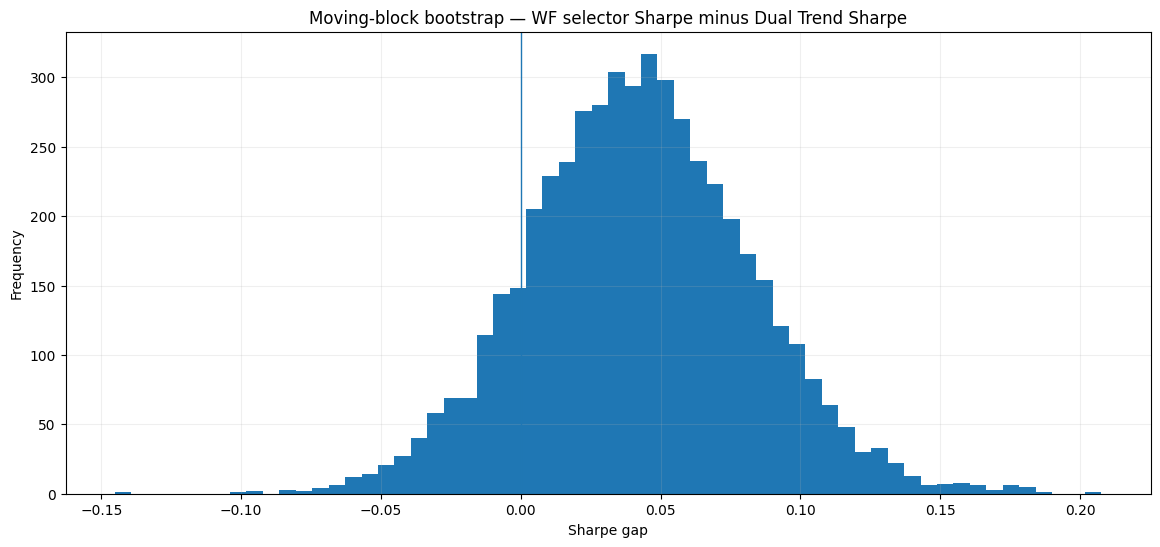

In [10]:
# ============================================================
# 9.10 — BOOTSTRAP DISTRIBUTION OF SHARPE GAP
# ============================================================
plt.figure(figsize=(14, 6))
plt.hist(bootstrap["sharpe_gap"], bins=60)
plt.axvline(0, linewidth=1)
plt.title("Moving-block bootstrap — WF selector Sharpe minus Dual Trend Sharpe")
plt.xlabel("Sharpe gap")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


## 9.11 Historical subperiod robustness

The common OOS sample is split into three pre-specified broad eras:

- 2011–2015
- 2016–2020
- 2021–2025

This is not an optimisation exercise. It is a stability diagnostic.


In [11]:
# ============================================================
# 9.11 — SUBPERIOD PERFORMANCE
# ============================================================
SUBPERIODS = {
    "2011-2015": ("2011-01-01", "2015-12-31"),
    "2016-2020": ("2016-01-01", "2020-12-31"),
    "2021-2025": ("2021-01-01", "2025-12-31"),
}

subperiod_rows = []

for label, (start, end) in SUBPERIODS.items():
    for strategy in common.columns:
        r = common.loc[start:end, strategy].dropna()
        m = metrics(r)

        subperiod_rows.append({
            "period": label,
            "strategy": strategy,
            **m,
        })

subperiod_performance = pd.DataFrame(subperiod_rows)

display(subperiod_performance)


,period,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week,positive_week_rate
0,2011-2015,WF_BLEND_SELECTOR,260,0.014129,0.023862,0.599927,0.890595,-0.026469,0.533792,-0.016361,0.519231
1,2011-2015,DUAL_TREND,260,0.014529,0.023763,0.618948,0.919723,-0.026469,0.548903,-0.016361,0.515385
2,2016-2020,WF_BLEND_SELECTOR,261,0.063626,0.034920,1.784886,2.243285,-0.040895,1.555847,-0.027334,0.616858
3,2016-2020,DUAL_TREND,261,0.063626,0.034920,1.784886,2.243285,-0.040895,1.555847,-0.027334,0.616858
4,2021-2025,WF_BLEND_SELECTOR,261,0.066230,0.035008,1.850347,2.964089,-0.031148,2.126261,-0.019899,0.616858
5,2021-2025,DUAL_TREND,261,0.058339,0.032532,1.760042,2.892943,-0.027458,2.124675,-0.017398,0.605364


## 9.12 Selector-framework sensitivity

We do **not** alter SuperbCommand or Dual Trend.

We only ask whether the blend-selection result survives a modest change in training-window length.

Three coarse, pre-specified selectors are tested:

- 3-year training / 1-year test
- 5-year training / 1-year test
- 7-year training / 1-year test

All select only among the same five coarse blend weights from Notebook 08.

This is a robustness check, not a search for the "best" training length.


In [12]:
# ============================================================
# 9.12 — TRAINING-WINDOW SENSITIVITY
# ============================================================
def build_blend_selector(blend_panel, train_years, first_test_year, last_test_year):
    selection_rows = []
    pieces = []

    for test_year in range(first_test_year, last_test_year + 1):
        train_start = test_year - train_years
        train_end = test_year - 1

        train = blend_panel[
            (blend_panel.index.year >= train_start)
            & (blend_panel.index.year <= train_end)
        ]

        test = blend_panel[blend_panel.index.year == test_year]

        ranks = []

        for name in blend_panel.columns:
            m = metrics(train[name])

            ranks.append({
                "blend": name,
                "train_sharpe": m["sharpe"],
                "train_calmar": m["calmar"],
            })

        rank_df = pd.DataFrame(ranks)
        rank_df["s"] = rank_df["train_sharpe"].fillna(-np.inf)
        rank_df["c"] = rank_df["train_calmar"].fillna(-np.inf)

        rank_df = rank_df.sort_values(
            ["s", "c", "blend"],
            ascending=[False, False, True],
        )

        selected = rank_df.iloc[0]["blend"]
        test_r = test[selected].dropna()

        if len(test_r):
            pieces.append(test_r)

        selection_rows.append({
            "test_year": test_year,
            "selected_blend": selected,
        })

    return pd.concat(pieces).sort_index(), pd.DataFrame(selection_rows)

WINDOWS = [3, 5, 7]

window_rows = []
window_selection_tables = {}

# Common first test year allows all three windows to have enough history.
WINDOW_FIRST_TEST_YEAR = 2013
WINDOW_LAST_TEST_YEAR = 2025

for w in WINDOWS:
    r, sel = build_blend_selector(
        blend_panel,
        train_years=w,
        first_test_year=WINDOW_FIRST_TEST_YEAR,
        last_test_year=WINDOW_LAST_TEST_YEAR,
    )

    window_selection_tables[w] = sel
    m = metrics(r)

    dual_same = dual.loc[r.index.min():r.index.max()].dropna()
    common_same = pd.concat([r.rename("wf"), dual_same.rename("dual")], axis=1).dropna()

    window_rows.append({
        "training_years": w,
        "start": r.index.min(),
        "end": r.index.max(),
        "cagr": m["cagr"],
        "sharpe": m["sharpe"],
        "sortino": m["sortino"],
        "max_drawdown": m["max_drawdown"],
        "dual_sharpe_same_period": metrics(common_same["dual"])["sharpe"],
        "sharpe_gap_vs_dual": metrics(common_same["wf"])["sharpe"] - metrics(common_same["dual"])["sharpe"],
        "unique_blends_selected": sel["selected_blend"].nunique(),
    })

window_sensitivity = pd.DataFrame(window_rows)

display(window_sensitivity)


,training_years,start,end,cagr,sharpe,sortino,max_drawdown,dual_sharpe_same_period,sharpe_gap_vs_dual,unique_blends_selected
0,3,2013-01-04,2025-12-26,0.054363,1.614271,2.350931,-0.040895,1.566601,0.047670,4
1,5,2013-01-04,2025-12-26,0.052851,1.600246,2.308318,-0.040895,1.566601,0.033644,3
2,7,2013-01-04,2025-12-26,0.051632,1.580696,2.272105,-0.040895,1.566601,0.014095,4


## 9.13 Bootstrap robustness of the best fixed benchmark itself

Dual Trend's unusually strong risk-adjusted performance also deserves skepticism.

This section estimates a bootstrap distribution for its Sharpe ratio and maximum drawdown rather than treating the observed 1.45 Sharpe as a fixed truth.


In [13]:
# ============================================================
# 9.13 — DUAL TREND BOOTSTRAP DISTRIBUTION
# ============================================================
dual_boot_summary = pd.DataFrame({
    "metric": [
        "Observed Sharpe",
        "Bootstrap median Sharpe",
        "Bootstrap Sharpe 2.5%",
        "Bootstrap Sharpe 97.5%",
        "Observed MaxDD",
        "Bootstrap median MaxDD",
        "Bootstrap MaxDD 2.5%",
        "Bootstrap MaxDD 97.5%",
    ],
    "value": [
        metrics(common["DUAL_TREND"])["sharpe"],
        bootstrap["dual_sharpe"].median(),
        bootstrap["dual_sharpe"].quantile(0.025),
        bootstrap["dual_sharpe"].quantile(0.975),
        metrics(common["DUAL_TREND"])["max_drawdown"],
        bootstrap["dual_max_drawdown"].median(),
        bootstrap["dual_max_drawdown"].quantile(0.025),
        bootstrap["dual_max_drawdown"].quantile(0.975),
    ],
})

display(dual_boot_summary)


,metric,value
0,Observed Sharpe,1.450324
1,Bootstrap median Sharpe,1.450281
2,Bootstrap Sharpe 2.5%,0.943038
3,Bootstrap Sharpe 97.5%,1.992930
4,Observed MaxDD,-0.040895
5,Bootstrap median MaxDD,-0.040895
6,Bootstrap MaxDD 2.5%,-0.063888
7,Bootstrap MaxDD 97.5%,-0.026183


## 9.14 Decision-oriented robustness scorecard

This scorecard intentionally avoids declaring the most complicated model the winner.

The WF selector earns evidence only when it survives a robustness test **relative to pure Dual Trend**.


In [14]:
# ============================================================
# 9.14 — ROBUSTNESS SCORECARD
# ============================================================
loo_win_share = (leave_one_year_out["sharpe_gap"] > 0).mean()
bootstrap_sharpe_win_prob = (bootstrap["sharpe_gap"] > 0).mean()
bootstrap_cagr_win_prob = (bootstrap["cagr_gap"] > 0).mean()
positive_window_count = int((window_sensitivity["sharpe_gap_vs_dual"] > 0).sum())

scorecard = pd.DataFrame([
    {
        "test": "Observed OOS Sharpe",
        "wf_selector_better": metrics(common["WF_BLEND_SELECTOR"])["sharpe"] > metrics(common["DUAL_TREND"])["sharpe"],
        "evidence": metrics(common["WF_BLEND_SELECTOR"])["sharpe"] - metrics(common["DUAL_TREND"])["sharpe"],
    },
    {
        "test": "Leave-one-year-out Sharpe majority",
        "wf_selector_better": loo_win_share > 0.5,
        "evidence": loo_win_share,
    },
    {
        "test": "Block-bootstrap P(Sharpe gap > 0)",
        "wf_selector_better": bootstrap_sharpe_win_prob > 0.5,
        "evidence": bootstrap_sharpe_win_prob,
    },
    {
        "test": "Block-bootstrap P(CAGR gap > 0)",
        "wf_selector_better": bootstrap_cagr_win_prob > 0.5,
        "evidence": bootstrap_cagr_win_prob,
    },
    {
        "test": "Training-window sensitivity majority",
        "wf_selector_better": positive_window_count >= 2,
        "evidence": f"{positive_window_count}/3 positive Sharpe gaps",
    },
])

display(scorecard)

print(
    "Robustness tests favouring WF selector:",
    int(scorecard["wf_selector_better"].sum()),
    "of",
    len(scorecard),
)


,test,wf_selector_better,evidence
0,Observed OOS Sharpe,True,0.031991
1,Leave-one-year-out Sharpe majority,True,1.0
2,Block-bootstrap P(Sharpe gap > 0),True,0.862
3,Block-bootstrap P(CAGR gap > 0),True,0.9882
4,Training-window sensitivity majority,True,3/3 positive Sharpe gaps


Robustness tests favouring WF selector: 5 of 5


## 9.15 Save outputs


In [15]:
# ============================================================
# 9.15 — SAVE OUTPUTS
# ============================================================
CONCENTRATION_PATH = PATHS["results"] / "09_excess_return_concentration.csv"
REMOVE_BEST_PATH = PATHS["results"] / "09_remove_best_years.csv"
LOO_PATH = PATHS["results"] / "09_leave_one_year_out.csv"
COST_PATH = PATHS["results"] / "09_cost_stress.csv"
BOOTSTRAP_PATH = PATHS["results"] / "09_block_bootstrap.csv"
BOOT_SUMMARY_PATH = PATHS["results"] / "09_block_bootstrap_summary.csv"
SUBPERIOD_PATH = PATHS["results"] / "09_subperiod_performance.csv"
WINDOW_PATH = PATHS["results"] / "09_selector_window_sensitivity.csv"
DUAL_BOOT_PATH = PATHS["results"] / "09_dualtrend_bootstrap_summary.csv"
SCORECARD_PATH = PATHS["results"] / "09_robustness_scorecard.csv"

excess_concentration.to_csv(CONCENTRATION_PATH, index=False)
remove_best_years.to_csv(REMOVE_BEST_PATH, index=False)
leave_one_year_out.to_csv(LOO_PATH, index=False)
cost_stress.to_csv(COST_PATH, index=False)
bootstrap.to_csv(BOOTSTRAP_PATH, index=False)
bootstrap_summary.to_csv(BOOT_SUMMARY_PATH, index=False)
subperiod_performance.to_csv(SUBPERIOD_PATH, index=False)
window_sensitivity.to_csv(WINDOW_PATH, index=False)
dual_boot_summary.to_csv(DUAL_BOOT_PATH, index=False)
scorecard.to_csv(SCORECARD_PATH, index=False)

print("Saved Notebook 09 outputs.")


Saved Notebook 09 outputs.


## 9.16 Validation suite

Notebook 09 passes only if:

- 2026 remains absent;
- bootstrap resampling is joint across the two strategies;
- exactly 5,000 block-bootstrap iterations are completed;
- block size remains fixed at 13 weeks;
- the robustness sample is identical for WF selector and Dual Trend;
- training-window sensitivity tests only 3, 5 and 7 years;
- all outputs are written.


In [16]:
# ============================================================
# 9.16 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = common.index.max() <= RESEARCH_END
checks["2026_absent"] = not (common.index.year == 2026).any()

checks["same_common_sample"] = (
    common["WF_BLEND_SELECTOR"].notna().all()
    and common["DUAL_TREND"].notna().all()
)

checks["bootstrap_5000_iterations"] = len(bootstrap) == 5000
checks["bootstrap_block_13_weeks"] = BLOCK_WEEKS == 13
checks["training_windows_fixed_3_5_7"] = WINDOWS == [3, 5, 7]

checks["outputs_written"] = all(
    p.exists()
    for p in [
        CONCENTRATION_PATH,
        REMOVE_BEST_PATH,
        LOO_PATH,
        COST_PATH,
        BOOTSTRAP_PATH,
        BOOT_SUMMARY_PATH,
        SUBPERIOD_PATH,
        WINDOW_PATH,
        DUAL_BOOT_PATH,
        SCORECARD_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 09 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 09 STATUS: PASS")
print("=" * 78)
print("Robustness, bootstrap and stress testing completed.")
print("No SuperbCommand or Dual Trend signal parameters were optimised.")
print("2026 final holdout: NOT ACCESSED")
print("Review robustness evidence before freezing the research architecture.")


                       check  passed
              holdout_absent    True
                 2026_absent    True
          same_common_sample    True
   bootstrap_5000_iterations    True
    bootstrap_block_13_weeks    True
training_windows_fixed_3_5_7    True
             outputs_written    True

NOTEBOOK 09 STATUS: PASS
Robustness, bootstrap and stress testing completed.
No SuperbCommand or Dual Trend signal parameters were optimised.
2026 final holdout: NOT ACCESSED
Review robustness evidence before freezing the research architecture.


In [17]:
# ============================================================
# 9.17 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "09",
    "notebook_name": "Robustness, Bootstrap & Monte Carlo Stress Testing",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "principal_models": [
        "WF_BLEND_SELECTOR",
        "DUAL_TREND_13_52__hier_inverse_vol",
    ],
    "bootstrap": {
        "method": "moving_block_bootstrap",
        "iterations": BOOTSTRAP_ITERATIONS,
        "block_weeks": BLOCK_WEEKS,
        "random_seed": RANDOM_SEED,
        "joint_resampling": True,
    },
    "cost_stress_extra_annual_bps": EXTRA_ANNUAL_DRAG_BPS,
    "selector_training_window_sensitivity_years": WINDOWS,
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "excess_concentration": str(CONCENTRATION_PATH),
        "remove_best_years": str(REMOVE_BEST_PATH),
        "leave_one_year_out": str(LOO_PATH),
        "cost_stress": str(COST_PATH),
        "block_bootstrap": str(BOOTSTRAP_PATH),
        "block_bootstrap_summary": str(BOOT_SUMMARY_PATH),
        "subperiod_performance": str(SUBPERIOD_PATH),
        "selector_window_sensitivity": str(WINDOW_PATH),
        "dualtrend_bootstrap_summary": str(DUAL_BOOT_PATH),
        "robustness_scorecard": str(SCORECARD_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "09_robustness_bootstrap_stress_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/09_robustness_bootstrap_stress_manifest.json


---

# End of Notebook 09

## Main question

\[
\boxed{\text{Is the apparent advantage of the WF blend selector robust enough to justify carrying it toward the final holdout?}}
\]

Notebook 09 does **not** search for a higher-performing model.

It tries to falsify the current finding through:

- leave-one-year-out tests;
- best-year removal;
- transaction-cost stress;
- moving-block bootstrap;
- broad subperiod testing;
- modest selector-window perturbations.

### Interpretation

If the WF selector's advantage disappears under modest perturbation, **pure Dual Trend should remain the conservative default**.

If it survives broadly, the selector becomes a serious challenger for the final frozen architecture.

### Final holdout

**2026 remains completely untouched.**
